In [4]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib as plt
from sklearn.preprocessing import StandardScaler


In [5]:
df = pd.read_excel("EduPro Online Platform.xlsx")

In [6]:
df

,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com
3,U00004,fthornton,23,Female,christensencatherine@outlook.com
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com
...,...,...,...,...,...
2995,U02996,rebeccamccoy,32,Male,james28@outlook.com
2996,U02997,jburke,21,Female,nramos@yahoo.com
2997,U02998,choikendra,33,Male,katherinebeck@hotmail.com
2998,U02999,rachelmalone,20,Male,rodgerserica@hotmail.com


In [7]:
xls = pd.ExcelFile("EduPro Online Platform.xlsx")
print(xls.sheet_names)

['Users', 'Teachers', 'Courses', 'Transactions']


load all the sheets 

In [8]:
users = pd.read_excel("EduPro Online Platform.xlsx", sheet_name="Users")
teachers = pd.read_excel("EduPro Online Platform.xlsx", sheet_name="Teachers")
courses = pd.read_excel("EduPro Online Platform.xlsx", sheet_name="Courses")
transactions = pd.read_excel("EduPro Online Platform.xlsx", sheet_name="Transactions")

show columns

In [9]:
print("Users Columns:")
print(users.columns)

print("\nTeachers Columns:")
print(teachers.columns)

print("\nCourses Columns:")
print(courses.columns)

print("\nTransactions Columns:")
print(transactions.columns)

Users Columns:
Index(['UserID', 'UserName', 'Age', 'Gender', 'Email'], dtype='object')

Teachers Columns:
Index(['TeacherID', 'TeacherName', 'Age', 'Gender', 'Expertise',
       'YearsOfExperience', 'TeacherRating'],
      dtype='object')

Courses Columns:
Index(['CourseID', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel',
       'CoursePrice', 'CourseDuration', 'CourseRating'],
      dtype='object')

Transactions Columns:
Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID'],
      dtype='object')


show dataset size

In [10]:
print(users.shape)
print(teachers.shape)
print(courses.shape)
print(transactions.shape)

(3000, 5)
(60, 7)
(60, 8)
(10000, 7)


transaction is main table
userId user table sathe jodase
courseId course table sathe jodase
TeacherId teacher table sathe jodase

Missing value check

In [11]:
print(users.isnull().sum())

print(teachers.isnull().sum())

print(courses.isnull().sum())

print(transactions.isnull().sum())

UserID      0
UserName    0
Age         0
Gender      0
Email       0
dtype: int64
TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64
CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64
TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64


In [12]:
courses.describe()

# teachers.describe()

# transactions.describe()

,CoursePrice,CourseDuration,CourseRating
count,60.000000,60.000000,60.000000
mean,92.986333,27.632500,3.097833
std,153.601506,16.092578,1.171232
min,0.000000,1.200000,1.130000
25%,0.000000,14.500000,2.107500
50%,0.000000,28.505000,3.065000
75%,133.615000,43.012500,4.102500
max,490.900000,49.730000,4.940000


In [13]:
teachers.describe()

,Age,YearsOfExperience,TeacherRating
count,60.000000,60.000000,60.000000
mean,38.450000,6.283333,3.125000
std,7.703015,4.715972,0.949797
min,27.000000,1.000000,1.050000
25%,32.000000,3.000000,2.487500
50%,36.500000,6.000000,3.275000
75%,46.250000,8.000000,3.827500
max,50.000000,24.000000,4.970000


In [14]:
transactions.describe()

,TransactionDate,Amount
count,10000,10000.000000
mean,2025-07-01 03:50:32.640000,91.132347
min,2025-01-01 00:00:00,0.000000
25%,2025-04-02 00:00:00,0.000000
50%,2025-06-30 00:00:00,0.000000
75%,2025-09-28 00:00:00,119.040000
max,2025-12-30 00:00:00,490.900000
std,NaN,152.063524


Merge dataset 

In [15]:
merged_df = transactions.merge(
    courses,
    on="CourseID",
    how="left"
)

merged_df = merged_df.merge(
    teachers,
    on="TeacherID",
    how="left"
)

merged_df.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72,Kimberly Miller,49,Male,Cybersecurity,24,4.58
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45,Kimberly Miller,49,Male,Cybersecurity,24,4.58
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98,Kimberly Miller,49,Male,Cybersecurity,24,4.58
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64,Kimberly Miller,49,Male,Cybersecurity,24,4.58
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14,Yolanda Levine,49,Female,Machine Learning,21,4.97


In [16]:
print(transactions.shape)
print(merged_df.shape)

(10000, 7)
(10000, 20)


Handle missing value 

In [17]:
merged_df.isnull().sum()

TransactionID        0
UserID               0
CourseID             0
TransactionDate      0
Amount               0
PaymentMethod        0
TeacherID            0
CourseName           0
CourseCategory       0
CourseType           0
CourseLevel          0
CoursePrice          0
CourseDuration       0
CourseRating         0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64

Aggregate transaction data at course level

In [18]:
course_summary = merged_df.groupby("CourseID").agg({
    "Amount":"sum",
    "TransactionID":"count",
    "CourseCategory":"first",
    "CourseType":"first",
    "CourseLevel":"first",
    "CoursePrice":"first",
    "CourseDuration":"first",
    "CourseRating":"first",
    "TeacherRating":"mean",
    "YearsOfExperience":"mean"
}).reset_index()

course_summary.rename(columns={
    "Amount":"CourseRevenue",
    "TransactionID":"EnrollmentCount"
}, inplace=True)

course_summary.head()

,CourseID,CourseRevenue,EnrollmentCount,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherRating,YearsOfExperience
0,CR00001,77453.92,164,Programming,Paid,Beginner,472.28,11.00,4.74,4.191646,16.682927
1,CR00002,0.00,149,Programming,Free,Intermediate,0.00,37.70,2.43,4.211409,17.013423
2,CR00003,0.00,173,Programming,Free,Beginner,0.00,19.53,3.85,4.079017,16.589595
3,CR00004,0.00,154,Programming,Free,Beginner,0.00,45.13,2.88,4.097987,15.896104
4,CR00005,0.00,166,Programming,Free,Beginner,0.00,28.68,1.28,4.058554,15.795181


In [19]:
course_summary.shape

(60, 11)

In [20]:
course_summary["EnrollmentCount"].describe()

count     60.000000
mean     166.666667
std       12.523424
min      140.000000
25%      157.500000
50%      166.000000
75%      174.750000
max      196.000000
Name: EnrollmentCount, dtype: float64

feature Enginerring 

In [21]:
level_map = {
    "Beginner": 0,
    "Intermediate": 1,
    "Advanced": 2
}

course_summary["CourseLevelEncoded"] = (
    course_summary["CourseLevel"].map(level_map)
)

course feature

In [22]:
def price_band(price):
    if price == 0:
        return "Free"
    elif price < 500:
        return "Low"
    elif price < 1000:
        return "Medium"
    else:
        return "High"

course_summary["PriceBand"] = course_summary["CoursePrice"].apply(price_band)

In [23]:
def duration_bucket(duration):
    if duration < 15:
        return "Short"
    elif duration < 30:
        return "Medium"
    else:
        return "Long"

course_summary["DurationBucket"] = course_summary["CourseDuration"].apply(duration_bucket)

In [24]:
def rating_tier(rating):
    if rating >= 4.5:
        return "Excellent"
    elif rating >= 3.5:
        return "Good"
    else:
        return "Average"

course_summary["RatingTier"] = course_summary["CourseRating"].apply(rating_tier)

Instructor features

In [25]:
def exp_bucket(exp):
    if exp < 5:
        return "Beginner"
    elif exp < 10:
        return "Intermediate"
    else:
        return "Expert"

course_summary["ExperienceBucket"] = course_summary["YearsOfExperience"].apply(exp_bucket)

Revenue per enrollment

In [26]:
course_summary["RevenuePerEnrollment"] = (
    course_summary["CourseRevenue"] /
    course_summary["EnrollmentCount"]
)

Past Average Revenue

In [27]:
course_summary["PastAverageRevenue"] = (
    course_summary["CourseRevenue"] /
    course_summary["EnrollmentCount"]
)

In [28]:
course_summary.head()

,CourseID,CourseRevenue,EnrollmentCount,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherRating,YearsOfExperience,CourseLevelEncoded,PriceBand,DurationBucket,RatingTier,ExperienceBucket,RevenuePerEnrollment,PastAverageRevenue
0,CR00001,77453.92,164,Programming,Paid,Beginner,472.28,11.00,4.74,4.191646,16.682927,0,Low,Short,Excellent,Expert,472.28,472.28
1,CR00002,0.00,149,Programming,Free,Intermediate,0.00,37.70,2.43,4.211409,17.013423,1,Free,Long,Average,Expert,0.00,0.00
2,CR00003,0.00,173,Programming,Free,Beginner,0.00,19.53,3.85,4.079017,16.589595,0,Free,Medium,Good,Expert,0.00,0.00
3,CR00004,0.00,154,Programming,Free,Beginner,0.00,45.13,2.88,4.097987,15.896104,0,Free,Long,Average,Expert,0.00,0.00
4,CR00005,0.00,166,Programming,Free,Beginner,0.00,28.68,1.28,4.058554,15.795181,0,Free,Medium,Average,Expert,0.00,0.00


In [29]:
course_summary.columns

Index(['CourseID', 'CourseRevenue', 'EnrollmentCount', 'CourseCategory',
       'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration',
       'CourseRating', 'TeacherRating', 'YearsOfExperience',
       'CourseLevelEncoded', 'PriceBand', 'DurationBucket', 'RatingTier',
       'ExperienceBucket', 'RevenuePerEnrollment', 'PastAverageRevenue'],
      dtype='object')

encode categorical cols

In [30]:
categorical_cols = [
    "CourseCategory",
    "CourseType",
    "PriceBand",
    "DurationBucket",
    "RatingTier",
    "ExperienceBucket"
]

course_encoded = pd.get_dummies(
    course_summary,
    columns=categorical_cols,
    drop_first=True
)

2. Normalize numerical features

In [31]:
scaler = StandardScaler()

numeric_cols = [
    "CoursePrice",
    "CourseDuration",
    "CourseRating",
    "TeacherRating",
    "YearsOfExperience",
    "RevenuePerEnrollment",
    "PastAverageRevenue"
]

course_encoded[numeric_cols] = scaler.fit_transform(
    course_encoded[numeric_cols]
)

3. Remove highly correlated or redundant features

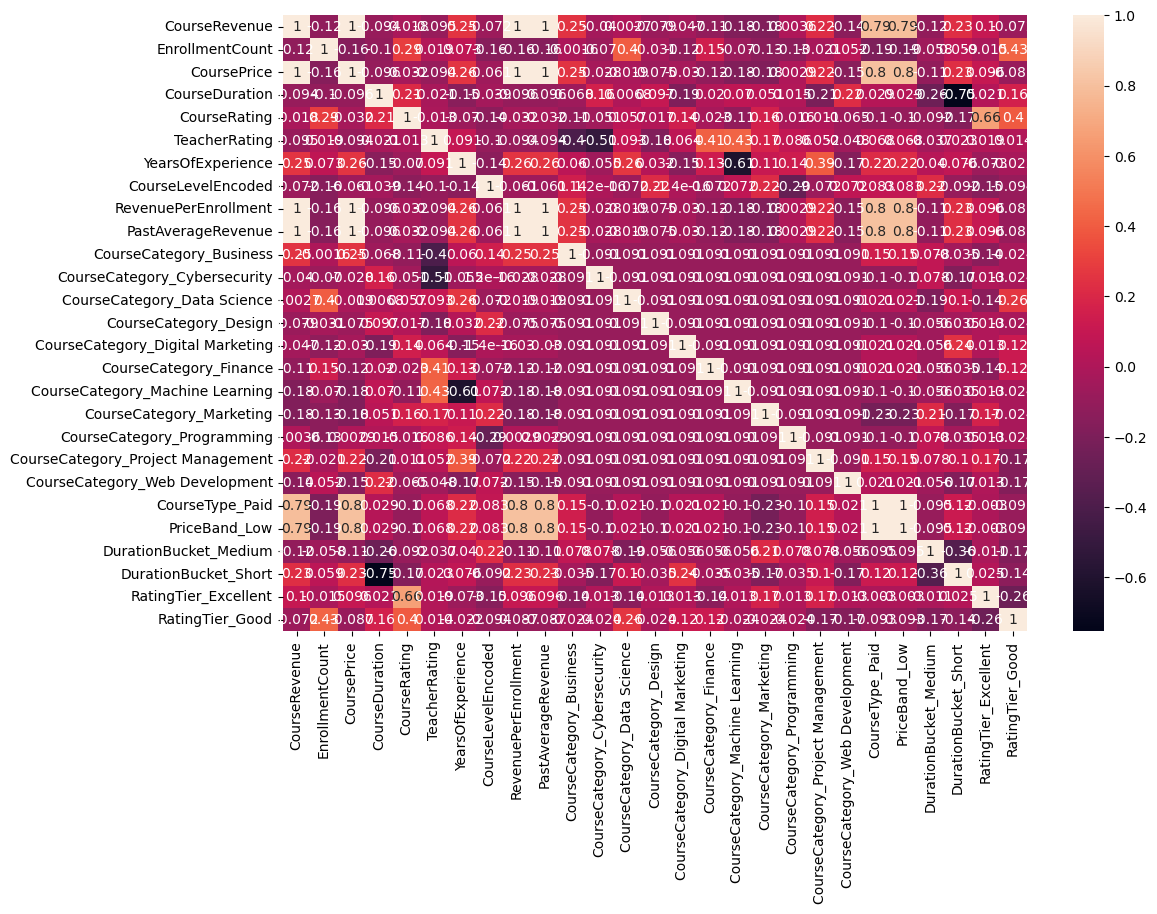

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = course_encoded.corr(numeric_only=True)

corr_matrix

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [33]:
corr_matrix

,CourseRevenue,EnrollmentCount,CoursePrice,CourseDuration,CourseRating,TeacherRating,YearsOfExperience,CourseLevelEncoded,RevenuePerEnrollment,PastAverageRevenue,...,CourseCategory_Marketing,CourseCategory_Programming,CourseCategory_Project Management,CourseCategory_Web Development,CourseType_Paid,PriceBand_Low,DurationBucket_Medium,DurationBucket_Short,RatingTier_Excellent,RatingTier_Good
CourseRevenue,1.000000,-0.116611,0.996722,-0.094198,-0.018298,-0.094761,0.253583,-7.193168e-02,0.996722,0.996722,...,-0.181750,0.003614,0.222952,-0.141826,0.792230,0.792230,-0.116358,0.227370,0.102789,-0.071554
EnrollmentCount,-0.116611,1.000000,-0.163356,-0.103414,0.294010,0.018949,0.073369,-1.571999e-01,-0.163356,-0.163356,...,-0.132725,-0.132725,-0.021042,0.051795,-0.194021,-0.194021,-0.057580,0.058888,-0.015030,0.430484
CoursePrice,0.996722,-0.163356,1.000000,-0.096051,-0.031973,-0.094174,0.258599,-6.059866e-02,1.000000,1.000000,...,-0.184067,0.002909,0.218688,-0.146374,0.802331,0.802331,-0.110080,0.229146,0.096221,-0.086978
CourseDuration,-0.094198,-0.103414,-0.096051,1.000000,0.209411,-0.020527,-0.145062,-3.877262e-02,-0.096051,-0.096051,...,0.051307,0.014652,-0.210831,0.224075,0.029313,0.029313,-0.264437,-0.753325,0.021357,0.163186
CourseRating,-0.018298,0.294010,-0.031973,0.209411,1.000000,-0.013037,-0.069666,-1.351552e-01,-0.031973,-0.031973,...,0.162036,-0.016052,0.011466,-0.065377,-0.102210,-0.102210,-0.092453,-0.168601,0.661018,0.396974
TeacherRating,-0.094761,0.018949,-0.094174,-0.020527,-0.013037,1.000000,0.090688,-1.010420e-01,-0.094174,-0.094174,...,0.173297,0.086002,0.052481,-0.048028,0.068083,0.068083,-0.036798,0.023316,0.018816,0.013819
YearsOfExperience,0.253583,0.073369,0.258599,-0.145062,-0.069666,0.090688,1.000000,-1.404169e-01,0.258599,0.258599,...,0.108037,0.136635,0.391045,-0.166753,0.215223,0.215223,0.039881,0.076332,-0.073457,-0.021894
CourseLevelEncoded,-0.071932,-0.157200,-0.060599,-0.038773,-0.135155,-0.101042,-0.140417,1.000000e+00,-0.060599,-0.060599,...,0.216225,-0.288300,-0.072075,0.072075,0.082676,0.082676,0.221036,-0.092009,-0.154446,-0.094197
RevenuePerEnrollment,0.996722,-0.163356,1.000000,-0.096051,-0.031973,-0.094174,0.258599,-6.059866e-02,1.000000,1.000000,...,-0.184067,0.002909,0.218688,-0.146374,0.802331,0.802331,-0.110080,0.229146,0.096221,-0.086978
PastAverageRevenue,0.996722,-0.163356,1.000000,-0.096051,-0.031973,-0.094174,0.258599,-6.059866e-02,1.000000,1.000000,...,-0.184067,0.002909,0.218688,-0.146374,0.802331,0.802331,-0.110080,0.229146,0.096221,-0.086978


enrollment model building

In [34]:
X = course_encoded.drop(
    columns=["EnrollmentCount", "CourseRevenue","CourseID","CourseLevel","RevenuePerEnrollment","PastAverageRevenue"]
)

y = course_encoded["EnrollmentCount"]

Train-Test Split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
print(y.name)

EnrollmentCount


Linear reggression

In [37]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

evalation

In [38]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 15.370757265864325
RMSE : 19.35543726131324
R2 : -1.0559125391400594


In [39]:
X.columns

Index(['CoursePrice', 'CourseDuration', 'CourseRating', 'TeacherRating',
       'YearsOfExperience', 'CourseLevelEncoded', 'CourseCategory_Business',
       'CourseCategory_Cybersecurity', 'CourseCategory_Data Science',
       'CourseCategory_Design', 'CourseCategory_Digital Marketing',
       'CourseCategory_Finance', 'CourseCategory_Machine Learning',
       'CourseCategory_Marketing', 'CourseCategory_Programming',
       'CourseCategory_Project Management', 'CourseCategory_Web Development',
       'CourseType_Paid', 'PriceBand_Low', 'DurationBucket_Medium',
       'DurationBucket_Short', 'RatingTier_Excellent', 'RatingTier_Good'],
      dtype='object')

Ridge regression

In [40]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("R2 Score:",
      r2_score(y_test, ridge_pred))

R2 Score: -0.11410104675399402


Lasso Regression

In [41]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("R2 Score:",
      r2_score(y_test, lasso_pred))

R2 Score: -0.003632341984069143


In [42]:
X.shape

(60, 23)

In [43]:
y.shape

(60,)

Random forest 

In [44]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rfenrollment_pred = rf.predict(X_test)

print("R2 Score:",
      r2_score(y_test, rfenrollment_pred))

R2 Score: 0.1287967073170736


In [45]:
rf.predict(X.iloc[[0]])

array([166.58])

In [46]:
import joblib
joblib.dump(rf,"enrollment_model.pkl")

['enrollment_model.pkl']

In [47]:
print(y.name)

EnrollmentCount


gradient bossting

In [48]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("R2 Score:",
      r2_score(y_test, gb_pred))

R2 Score: -0.12522339715287178


In [49]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print(scores.mean())

[-0.13866749 -0.42990386 -0.00601314  0.0217582   0.0061034 ]
-0.10934457717204112


course revenue prediction

In [50]:
X = course_encoded.drop(
    columns=[
        "CourseID",
        "CourseLevel",
        "EnrollmentCount",
        "CourseRevenue",
        "RevenuePerEnrollment",
        "PastAverageRevenue"
    ]
)

y = course_encoded["CourseRevenue"]

In [51]:
course_summary["CourseRevenue"].describe()

count       60.000000
mean     15188.724500
std      25409.721911
min          0.000000
25%          0.000000
50%          0.000000
75%      20858.060000
max      85416.600000
Name: CourseRevenue, dtype: float64

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
print(X.columns.tolist())

['CoursePrice', 'CourseDuration', 'CourseRating', 'TeacherRating', 'YearsOfExperience', 'CourseLevelEncoded', 'CourseCategory_Business', 'CourseCategory_Cybersecurity', 'CourseCategory_Data Science', 'CourseCategory_Design', 'CourseCategory_Digital Marketing', 'CourseCategory_Finance', 'CourseCategory_Machine Learning', 'CourseCategory_Marketing', 'CourseCategory_Programming', 'CourseCategory_Project Management', 'CourseCategory_Web Development', 'CourseType_Paid', 'PriceBand_Low', 'DurationBucket_Medium', 'DurationBucket_Short', 'RatingTier_Excellent', 'RatingTier_Good']


Random forest for course revenue 

In [79]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

rf_revenue = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_revenue.fit(X_train, y_train)

pred = rf_revenue.predict(X_test)

rf_r2 = r2_score(y_test, pred)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE :", mean_squared_error(y_test, pred)**0.5)
print("R2 :", rf_r2)

MAE : 4744.506766666671
RMSE : 6807.692075866243
R2 : 0.9402921882760937


Linear regreesion

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_revenue = LinearRegression()

lr_revenue.fit(X_train, y_train)

lr_pred = lr_revenue.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE :", mean_squared_error(y_test, lr_pred)**0.5)
print("R2 :", lr_r2)

MAE : 3798.137219712035
RMSE : 4572.147076182148
R2 : 0.9730678061313928


Ridge reggression

In [56]:
from sklearn.linear_model import Ridge

ridge_revenue = Ridge(alpha=1.0)

ridge_revenue.fit(X_train, y_train)

ridge_pred = ridge_revenue.predict(X_test)
ridge_r2 = r2_score(y_test, ridge_pred)

print("MAE :", mean_absolute_error(y_test, ridge_pred))
print("RMSE :", mean_squared_error(y_test, ridge_pred)**0.5)
print("R2 :", ridge_r2)

MAE : 1996.0779166600278
RMSE : 3247.6957874921923
R2 : 0.9864111710653781


In [78]:

joblib.dump(rf_revenue, "revenue_model.pkl")

['revenue_model.pkl']

Lasso regression

In [58]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

lasso_r2 = r2_score(y_test, lasso_pred)
print("MAE :", mean_absolute_error(y_test, lasso_pred))
print("RMSE :", mean_squared_error(y_test, lasso_pred)**0.5)
print("R2 :",lasso_r2)

MAE : 3797.2371744044826
RMSE : 4570.5655675533135
R2 : 0.9730864346355629


gradient bossting

In [59]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_r2 = r2_score(y_test, gb_pred)
print("MAE :", mean_absolute_error(y_test, gb_pred))
print("RMSE :", mean_squared_error(y_test, gb_pred)**0.5)
print("R2 :", gb_r2)

MAE : 5039.372100076808
RMSE : 6550.206437662665
R2 : 0.9447233999620469


feature importance 

In [60]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                             Feature  Importance
1                     CourseDuration    0.214277
2                       CourseRating    0.194842
8        CourseCategory_Data Science    0.114608
3                      TeacherRating    0.092553
22                   RatingTier_Good    0.081200
4                  YearsOfExperience    0.077439
5                 CourseLevelEncoded    0.050704
10  CourseCategory_Digital Marketing    0.044814
13          CourseCategory_Marketing    0.029671
0                        CoursePrice    0.019570


comparisoon table 

In [61]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "R2 Score": [
        lr_r2,
        ridge_r2,
        lasso_r2,
        rf_r2,
        gb_r2
    ]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.973068
1   Ridge Regression  0.986411
2   Lasso Regression  0.973086
3      Random Forest  0.940292
4  Gradient Boosting  0.944723


category revenue analysis

In [62]:
category_revenue = merged_df.groupby(
    "CourseCategory"
)["Amount"].sum().reset_index()

print(category_revenue)

             CourseCategory     Amount
0   Artificial Intelligence  202750.67
1                  Business  181527.58
2             Cybersecurity   59139.00
3              Data Science   77052.32
4                    Design   43113.72
5         Digital Marketing   56261.32
6                   Finance   28106.20
7          Machine Learning     133.38
8                 Marketing       0.00
9               Programming   77453.92
10       Project Management  169103.21
11          Web Development   16682.15


bar chart

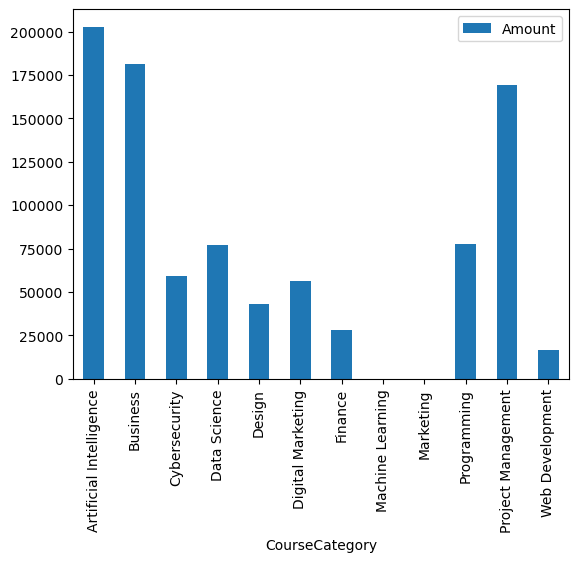

In [63]:
import matplotlib.pyplot as plt

category_revenue.plot(
    x="CourseCategory",
    y="Amount",
    kind="bar"
)

plt.show()

Busssiness insights

1. Paid vs Free Courses Revenue

In [64]:
course_summary.groupby("CourseType")["CourseRevenue"].mean()

CourseType
Free        0.000000
Paid    41423.794091
Name: CourseRevenue, dtype: float64

2. Course Price Impact

In [65]:

course_summary[["CoursePrice","CourseRevenue"]].corr()

,CoursePrice,CourseRevenue
CoursePrice,1.000000,0.996722
CourseRevenue,0.996722,1.000000


3. Teacher Rating Impact

In [66]:
course_summary[["TeacherRating","CourseRevenue"]].corr()

,TeacherRating,CourseRevenue
TeacherRating,1.000000,-0.094761
CourseRevenue,-0.094761,1.000000


4. Category Performance

In [67]:
category_revenue = merged_df.groupby("CourseCategory")["Amount"].sum().sort_values(ascending=False)

print(category_revenue)

CourseCategory
Artificial Intelligence    202750.67
Business                   181527.58
Project Management         169103.21
Programming                 77453.92
Data Science                77052.32
Cybersecurity               59139.00
Digital Marketing           56261.32
Design                      43113.72
Finance                     28106.20
Web Development             16682.15
Machine Learning              133.38
Marketing                       0.00
Name: Amount, dtype: float64


5. Course Rating Impact

In [68]:
course_summary[["CourseRating","CourseRevenue"]].corr()

,CourseRating,CourseRevenue
CourseRating,1.000000,-0.018298
CourseRevenue,-0.018298,1.000000


In [69]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [70]:
print(X.columns.tolist())

['CoursePrice', 'CourseDuration', 'CourseRating', 'TeacherRating', 'YearsOfExperience', 'CourseLevelEncoded', 'CourseCategory_Business', 'CourseCategory_Cybersecurity', 'CourseCategory_Data Science', 'CourseCategory_Design', 'CourseCategory_Digital Marketing', 'CourseCategory_Finance', 'CourseCategory_Machine Learning', 'CourseCategory_Marketing', 'CourseCategory_Programming', 'CourseCategory_Project Management', 'CourseCategory_Web Development', 'CourseType_Paid', 'PriceBand_Low', 'DurationBucket_Medium', 'DurationBucket_Short', 'RatingTier_Excellent', 'RatingTier_Good']


In [71]:
import os
print(os.getcwd())

C:\Users\Admin\project1


In [72]:
print(X.iloc[[0]])

   CoursePrice  CourseDuration  CourseRating  TeacherRating  \
0     2.490174       -1.042273      1.413918       0.739337   

   YearsOfExperience  CourseLevelEncoded  CourseCategory_Business  \
0           0.799758                   0                    False   

   CourseCategory_Cybersecurity  CourseCategory_Data Science  \
0                         False                        False   

   CourseCategory_Design  ...  CourseCategory_Marketing  \
0                  False  ...                     False   

   CourseCategory_Programming  CourseCategory_Project Management  \
0                        True                              False   

   CourseCategory_Web Development  CourseType_Paid  PriceBand_Low  \
0                           False             True           True   

   DurationBucket_Medium  DurationBucket_Short  RatingTier_Excellent  \
0                  False                  True                  True   

   RatingTier_Good  
0            False  

[1 rows x 23 columns]


In [73]:
print(rf.predict(X.iloc[[0]]))
print(ridge.predict(X.iloc[[0]]))

[166.58]
[162.48227797]


In [74]:
course_encoded["EnrollmentCount"].describe()

count     60.000000
mean     166.666667
std       12.523424
min      140.000000
25%      157.500000
50%      166.000000
75%      174.750000
max      196.000000
Name: EnrollmentCount, dtype: float64

In [75]:
print(type(rf))
print(rf.predict(X.iloc[[0]]))
print(y.iloc[0])

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
[166.58]
77453.92


In [76]:
# rf.predict(X.iloc[[0]])
rf_revenue.predict(X.iloc[[0]])

array([63968.1589])

In [77]:
print(course_encoded["CourseRevenue"].iloc[0])

77453.92
